In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pandas_ta as ta
import numpy as np

In [18]:
df = pd.read_csv("./coins/btc(krw)_2020-2025.csv")
df['date'] = pd.to_datetime(df['date'])

In [3]:
df2 = df.copy()

## ta.atr 
- 컬럼명 ATRr_length로 나옴
- length 파라미터로 기간 설정, 디폴트 14
- 결측치 말고는 추가 전처리 필요 X

In [63]:
df2.ta.atr(append=True)

0                NaN
1                NaN
2                NaN
3                NaN
4                NaN
            ...     
2082    2.830664e+06
2083    2.721403e+06
2084    2.690660e+06
2085    2.656255e+06
2086    2.665808e+06
Name: ATRr_14, Length: 2087, dtype: float64

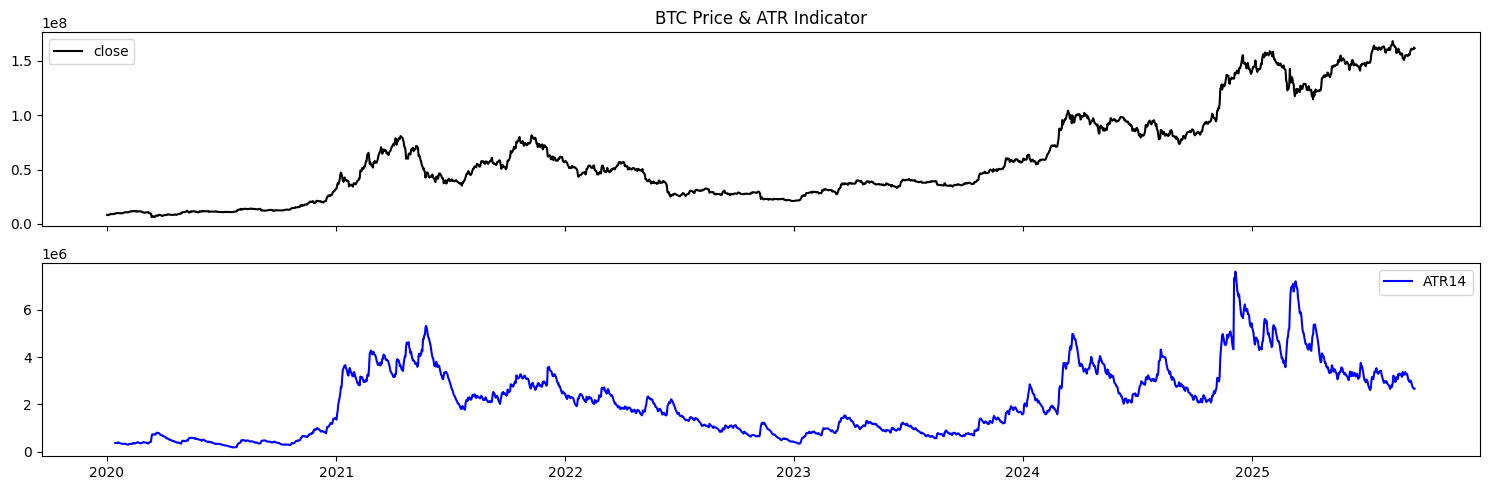

In [76]:
fig,ax = plt.subplots(2,1,figsize=(15,5),sharex=True)
ax.flatten()
ax[0].plot(df2['date'],df2['close'],label='close',color='black')
ax[0].legend()
ax[1].plot(df2['date'],df2['ATRr_14'],label='ATR14',color='blue')
ax[1].legend()
ax[0].set_title("BTC Price & ATR Indicator")
plt.tight_layout()
plt.show()

## ta.bbands()
- ta.bbands(length,std,append), 디폴트 5,2
- 생성 컬럼 명: 
    - BBL_length_std: 하단선,   
    - BBM_length_std:중심선,   
    - BBU_length_std: 상단선,    
    - BBB_length_std:밴드폭(%),    
    - BBP_length_std: 현재가격의 밴드내 위치
- 결측치 말고 추가 전처리 필요 X

In [77]:
df2.ta.bbands(append=True)

,BBL_5_2.0_2.0,BBM_5_2.0_2.0,BBU_5_2.0_2.0,BBB_5_2.0_2.0,BBP_5_2.0_2.0
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,7.969817e+06,8349400.0,8.728983e+06,9.092460,0.637783
...,...,...,...,...,...
2082,1.545948e+08,159204600.0,1.638144e+08,5.791009,0.644410
2083,1.582693e+08,160182200.0,1.620951e+08,2.388378,0.540724
2084,1.599907e+08,160611000.0,1.612313e+08,0.772439,0.575768
2085,1.595175e+08,160969400.0,1.624213e+08,1.803928,0.912429


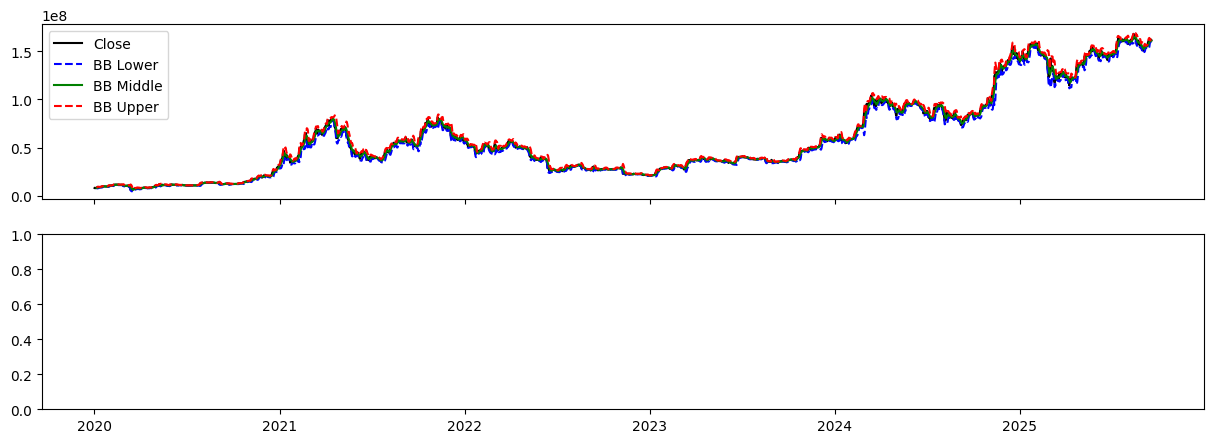

In [80]:
fig, ax = plt.subplots(2, 1, figsize=(15,5), sharex=True)

# 종가
ax[0].plot(df2['date'], df2['close'], label='Close', color='black')

# 볼린저 밴드
ax[0].plot(df2['date'], df2['BBL_5_2.0_2.0'], label='BB Lower', color='blue', linestyle='--')
ax[0].plot(df2['date'], df2['BBM_5_2.0_2.0'], label='BB Middle', color='green')
ax[0].plot(df2['date'], df2['BBU_5_2.0_2.0'], label='BB Upper', color='red', linestyle='--')

ax[0].legend()


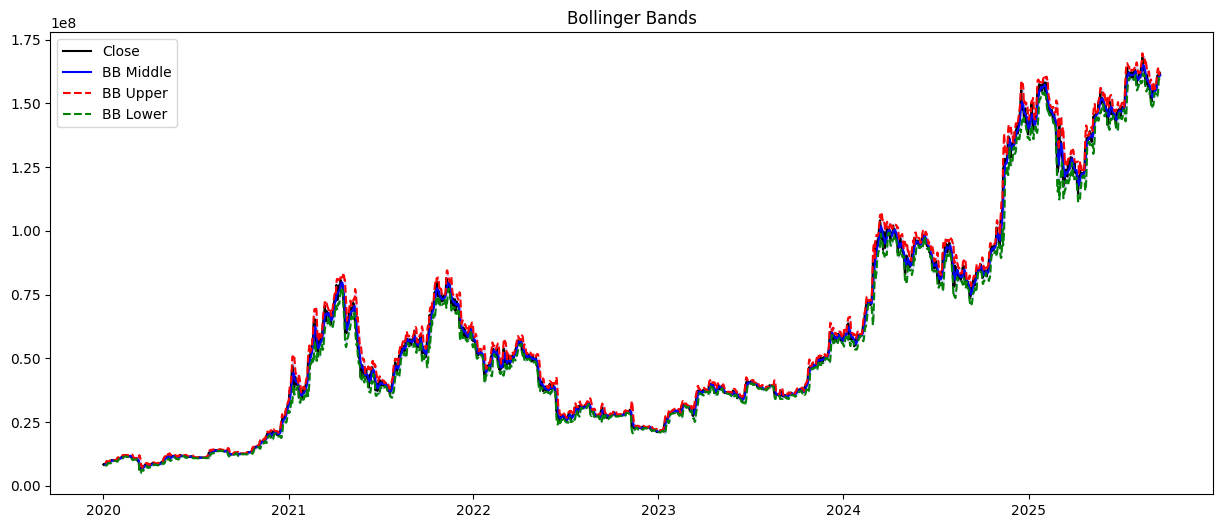

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,1,figsize=(15,6))

# 종가
ax.plot(df2['date'], df2['close'], label='Close', color='black')

# 볼린저 밴드
ax.plot(df2['date'], df2['BBM_5_2.0_2.0'], label='BB Middle', color='blue')
ax.plot(df2['date'], df2['BBU_5_2.0_2.0'], label='BB Upper', color='red', linestyle='--')
ax.plot(df2['date'], df2['BBL_5_2.0_2.0'], label='BB Lower', color='green', linestyle='--')

# 밴드 영역 음영처리
ax.fill_between(df2['date'], 
                df2['BBL_5_2.0_2.0'], 
                df2['BBU_5_2.0_2.0'], 
                color='blue', alpha=0.1)

ax.set_title("Bollinger Bands")
ax.legend()
plt.show()


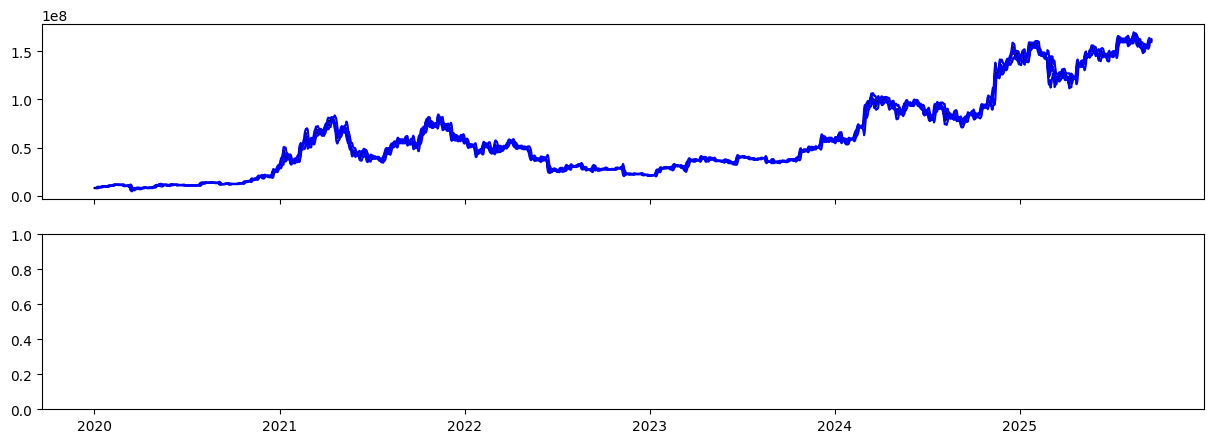

In [79]:
fig,ax = plt.subplots(2,1,figsize=(15,5),sharex=True)
ax.flatten()
ax[0].plot(df2['date'],df2['close'],label='close',color='black')
ax[0].plot(df2['date'],df2['BBL_5_2.0_2.0'],label='close',color='blue')
ax[0].plot(df2['date'],df2['BBM_5_2.0_2.0'],label='close',color='blue')
ax[0].plot(df2['date'],df2['BBU_5_2.0_2.0'],label='close',color='blue')

## ta.supertrend()
- ta.supertrend(length,multipler,append) 디폴트 7,3
- 컬럼명
    - SUPERT_length_multipler: Supertrend 기준선
    - SUPERd_length_multipler: 추세 방향(1=상승,-1=하락)
    - SUPERl_length_multipler: Long trend line (상승 구간에서 활성화됨)
    - SUPERTs_length_multipler: Short trend line (하락 구간에서 활성화됨)
- 결측치 처리, 롱숏라인은 시각화 용도로만 사용.


In [11]:
df2.ta.supertrend(append=True)

,SUPERT_7_3.0,SUPERTd_7_3.0,SUPERTl_7_3.0,SUPERTs_7_3.0
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
2082,1.528170e+08,1.0,1.528170e+08,NaN
2083,1.533547e+08,1.0,1.533547e+08,NaN
2084,1.534967e+08,1.0,1.534967e+08,NaN
2085,1.541552e+08,1.0,1.541552e+08,NaN


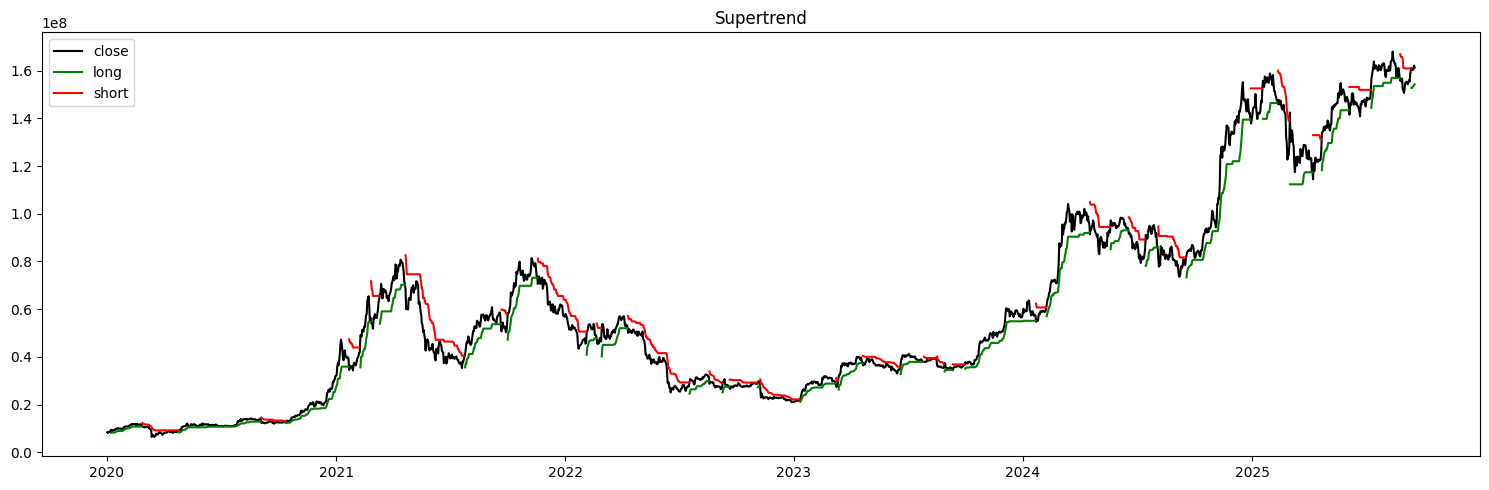

In [12]:
plt.figure(figsize=(15,5))
plt.plot(df2['date'],df2['close'],color='black',label = 'close')
plt.plot(df2['date'],df2['SUPERTl_7_3.0'],color = 'green',label='long')
plt.plot(df2['date'],df2['SUPERTs_7_3.0'],color = 'red',label='short')
plt.legend()
plt.title('Supertrend')
plt.tight_layout()
plt.show()

## ta.macd
- ta.macd(fast,slow,signal,append) 디폴트12,26,9
- 컬럼명
    - `MACD_fast_slow_signal`: MACD Line
    - `MACDs_fast_slow_signal`: Signal Line
    - `MACDh_fast_slow_signal`: Histogram
- 결측치 처리&컬 컬럼 전체 다쓸지 히스토그램만쓸지 고민

In [13]:
macd = df2.ta.macd(fast=12,slow=9,signal=26,append=True)
macd.head(40)

,MACD_9_12_26,MACDh_9_12_26,MACDs_9_12_26
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,NaN


## 전체 처리
ta.strategy(): 여러 기술 지표를 한번에 추가
- df.ta.strategy("All")   # 가능한 모든 지표 다 붙이기 (엄청 많음)   
df.ta.strategy("Momentum")  # 모멘텀 지표 세트   
df.ta.strategy("Trend")     # 추세 지표 세트   
df.ta.strategy(ta_list)   # 원하는 지표 추가    
- 현재 버젼에서는 지원 안함 pandas-ta-classic으로 이동하는 추세 이거는 mvp 이후 결정

## EDA
-> MVP이므로 깊게는 하지는 않겠음

In [3]:
df = pd.read_csv("../coins/btc(krw)_2020-2025.csv")
df['date'] = pd.to_datetime(df['date'])
df.ta.atr(append=True)
df.ta.bbands(append=True)
df.ta.supertrend(append=True)
df.drop(['SUPERTl_7_3.0','SUPERTs_7_3.0'],axis=1,inplace=True)
df.ta.macd(append=True)
df.ta.rsi(append=True)
df['ema50']=df['close'].ewm(span=50).mean()
df['target'] = np.where((df['close'].shift(-1) -df['close'])>0,1,0) # 1이면 상승 0이면 하락
df = df.set_index('date').copy()

In [4]:
# 20년도 부터
df = df.loc['2020-01-01 09:00:00':, :]
df.head()

,open,high,low,close,volume,ATRr_14,BBL_5_2.0_2.0,BBM_5_2.0_2.0,BBU_5_2.0_2.0,BBB_5_2.0_2.0,BBP_5_2.0_2.0,SUPERT_7_3.0,SUPERTd_7_3.0,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9,RSI_14,ema50,target
date,,,,,,,,,,,,,,,,,,,
2020-01-01 09:00:00,8308000.0,8387000.0,8287000.0,8300000.0,1030.458147,272854.235736,8.211975e+06,8374200.0,8.536425e+06,3.874389,0.271305,8.784786e+06,-1.0,-100586.119009,25874.838113,-126460.957123,43.612429,8.739449e+06,0
2020-01-02 09:00:00,8300000.0,8310000.0,8026000.0,8037000.0,2054.039566,273650.361755,7.970431e+06,8295200.0,8.619969e+06,7.830284,0.102486,8.784786e+06,-1.0,-120493.394695,4774.049943,-125267.444637,37.138339,8.711483e+06,1
2020-01-03 09:00:00,8038000.0,8525000.0,7910000.0,8474000.0,5887.008808,298032.478772,7.974978e+06,8292800.0,8.610622e+06,7.665010,0.785065,8.784786e+06,-1.0,-99856.720149,20328.579590,-120185.299740,50.331763,8.702034e+06,1
2020-01-04 09:00:00,8476000.0,8520000.0,8382000.0,8482000.0,1987.266881,286601.587432,7.959741e+06,8321000.0,8.682259e+06,8.683065,0.722832,8.784786e+06,-1.0,-81912.240433,30618.447446,-112530.687878,50.536432,8.693284e+06,0
2020-01-05 09:00:00,8483000.0,8645000.0,8436000.0,8454000.0,2807.832172,281058.616901,7.969817e+06,8349400.0,8.728983e+06,9.092460,0.637783,8.784786e+06,-1.0,-69153.320536,34701.893874,-103855.214410,49.763510,8.683774e+06,1


### 타겟 분포 확인

In [ ]:
df.target.value_counts(normalize=True)  # 균등 분포

target
1    0.518927
0    0.481073
Name: proportion, dtype: float64

### 결측치 확인

In [ ]:
df.isna().sum() # OK

open             0
high             0
low              0
close            0
volume           0
ATRr_14          0
BBL_5_2.0_2.0    0
BBM_5_2.0_2.0    0
BBU_5_2.0_2.0    0
BBB_5_2.0_2.0    0
BBP_5_2.0_2.0    0
SUPERT_7_3.0     0
SUPERTd_7_3.0    0
MACD_12_26_9     0
MACDh_12_26_9    0
MACDs_12_26_9    0
RSI_14           0
ema50            0
target           0
dtype: int64

### 상관관계

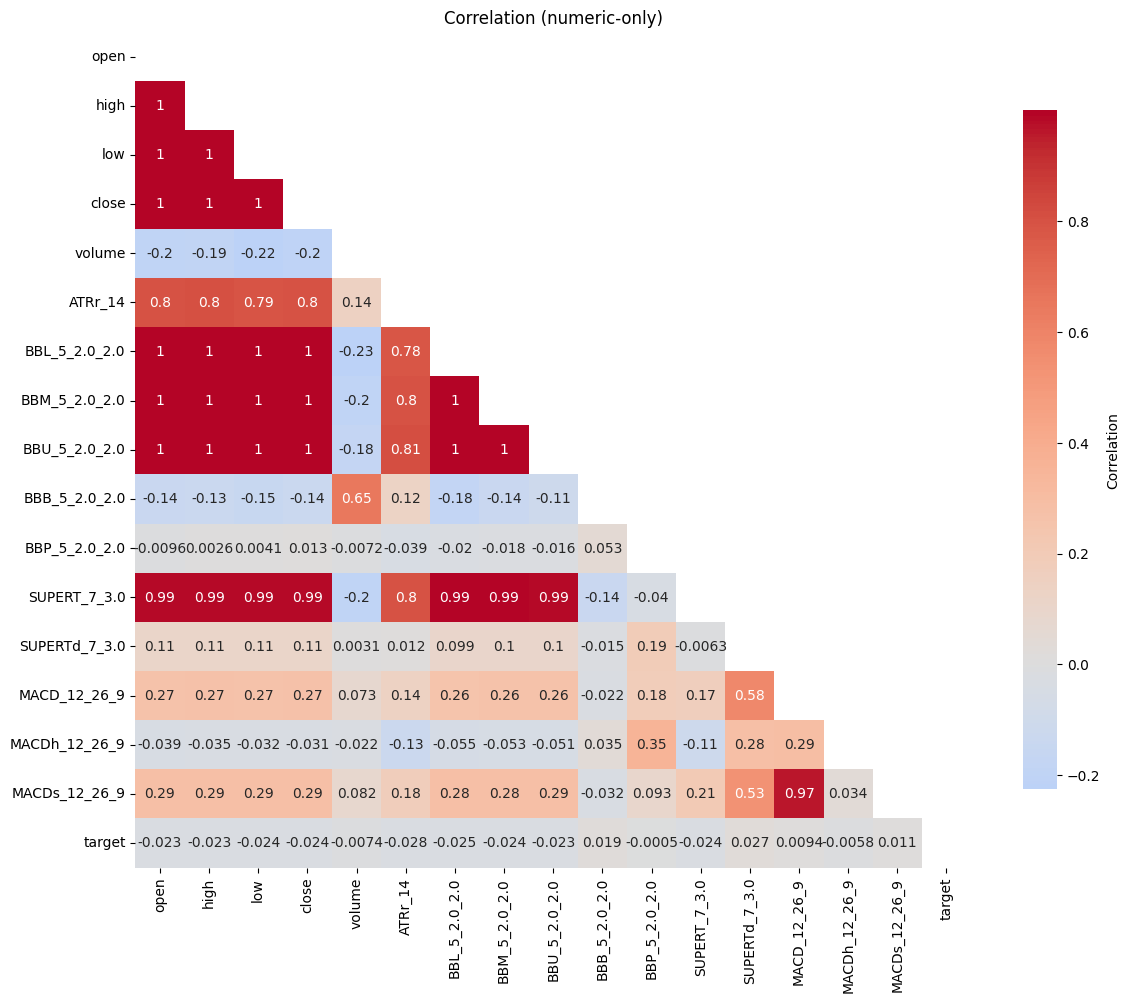

In [43]:

num = df.select_dtypes(include=[np.number]).copy()
corr = num.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True, square=True,
            cbar_kws={"shrink":0.8, "label":"Correlation"})
plt.title("Correlation (numeric-only)")
plt.tight_layout()
plt.show()